In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [3]:
set.seed(123)

In [4]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [5]:
l1_degs <- map_dfr(stims, function(s){
                map_dfr(celltypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L1_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv")))
                            
        })
    })

In [6]:
l2_degs <- map_dfr(stims, function(s){
                map_dfr(subtypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L2_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv")))
                            
        })
    })

### 3A. PCA IFNg LogFC

In [7]:
stim_select <- "IFNg"

In [8]:
l2_sig_genes <- l2_degs %>% filter(stim == stim_select & Significant == "Yes") %>% pull(gene) %>% unique()

In [9]:
pca_df <- l2_degs %>% 
    filter(stim == stim_select & gene %in% l2_sig_genes) %>%
    select(gene, median_log2FC, celltype) %>% 
    pivot_wider(names_from = celltype, values_from = median_log2FC) %>% 
    tibble::column_to_rownames("gene")

pca_df[is.na(pca_df)] <- 0

pca_df <- t(pca_df)

In [10]:
pca_result <- prcomp(pca_df, scale = T, center = T)  # Scale the data for PCA

pc_scores <- as.data.frame(pca_result$x[, 1:2])

pc_scores$Sample <- rownames(pc_scores)
pc_scores$Stim <- pc_scores$Sample %>% stringr::str_extract("[^_]+$")
pc_scores$Subtype <- pc_scores$Sample %>% stringr::str_extract("[^_]*")

pc_scores$Subtype <- factor(pc_scores$Subtype, levels = subtypes)

null device 
          1

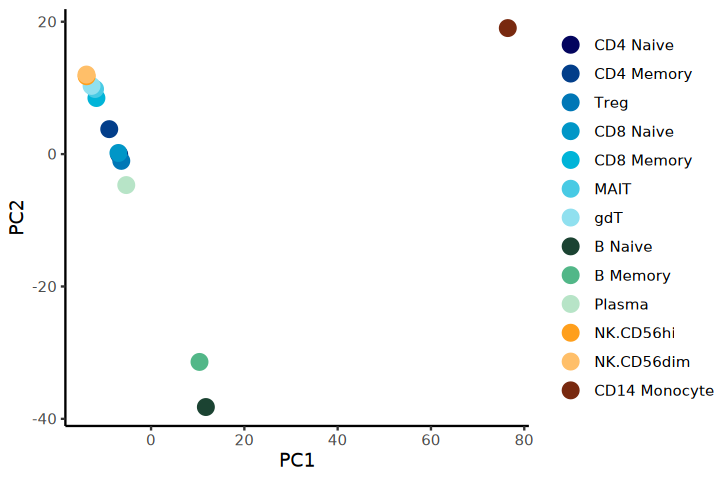

In [16]:
fig.size(4,6)
#pdf(file.path(fig_dir, "Fig2", glue("{stim}_PCA_Scatterplot.pdf")), height = 4, width = 6)
ggplot(pc_scores, aes(x = PC1, y = PC2, color = Subtype)) +
    geom_point(size = 4) +
    labs(x = "PC1", y = "PC2") +
    theme_classic() + 
    scale_color_manual(values=subtype_cols) + 
    theme(legend.title = element_blank()) 
dev.off()

### 3B. IFNg DEGs L1 Upset Plot

In [17]:
# IFNg responding cell types
celltypes <- c("Tcell", "Bcell", "Monocyte")

In [18]:
l1_degs_select <- l1_degs %>% filter(stim == stim_select & Significant == "Yes")
l1_degs_select$gene_sign <- ifelse(l1_degs_select$median_log2FC > 0, paste0("+", l1_degs_select$gene),
                                                      paste0("-", l1_degs_select$gene))

In [19]:
upset_df <- l1_degs_select %>% 
        select(gene_sign, celltype) %>%
  mutate(value = TRUE) %>%
  distinct() %>%
  pivot_wider(
    names_from = celltype,
    values_from = value,
    values_fill = FALSE
  )

In [20]:
df_mod <- l1_degs_select %>% group_by(gene_sign) %>% summarise(log2FC = mean(median_log2FC)) 
    
upset_df$gene <- gsub("[-a+]", "", upset_df$gene_sign)

upset_df_final <- left_join(upset_df, df_mod[,c("gene_sign", "log2FC")])

Joining with `by = join_by(gene_sign)`


In [21]:
upset_df_final$Direction <- ifelse(upset_df_final$log2FC > 0, "Upreg", "Downreg")
upset_df_final$Direction <- factor(upset_df_final$Direction, levels = c("Upreg", "Downreg"))

In [22]:
# define order of intersection groups
intersection_list <- list(c("Monocyte"),c("Bcell"),
                    c("Monocyte", "Bcell"),
                    c("Bcell", "Tcell"),c("Monocyte", "Bcell", "Tcell"))

Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”


null device 
          1

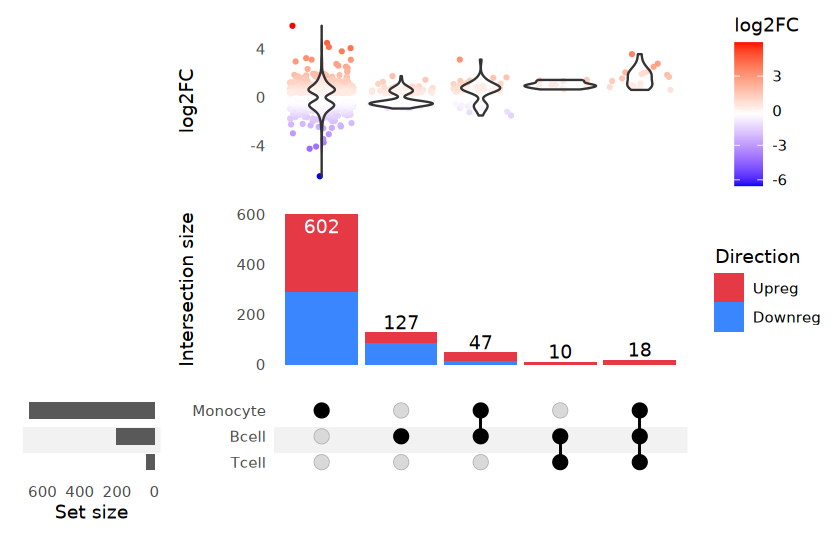

In [25]:
fig.size(4.5,7)
#pdf(file.path(fig_dir, "Fig2", glue("{stim}_Upset_Plot.pdf")), height = 4, width = 7)
ComplexUpset::upset(
        upset_df_final,
        celltypes,
        intersections=intersection_list,
        sort_intersections=FALSE,
        name = "",
    base_annotations=list(
        'Size'=(
            ComplexUpset::intersection_size(
                mode="exclusive_intersection",
                mapping=aes(fill=Direction),
                size=0,
                text=list(check_overlap=TRUE))+ scale_fill_manual(values=c(
            'Upreg'='#e63946', 'Downreg'='#3a86ff')
            )
        )
    ),
       annotations = list(
    'log2FC'=(
        ggplot(mapping=aes(y=log2FC)) + 
        geom_jitter(aes(color=log2FC), na.rm=T, size = 0.7) + 
        geom_violin(alpha=0.5, na.rm=T, scale = "area") + 
        #ggrepel::geom_text_repel(label = upset_df_label$label, force = 100) + 
        scale_color_gradientn(colors = c("blue", "white", "red"))
            )
        ),
        width_ratio = 0.25,
        min_size =10,
        themes=ComplexUpset::upset_default_themes(panel.grid = element_blank())
       
    )
dev.off()

### 3C. IFNa IFNg overlap barplot

In [95]:
# categorize genes as IFNa or IFNg specific or both
deg_count <- l2_degs %>% filter(stim %in% c("IFNa", "IFNg") & Significant == "Yes") %>%
  group_by(celltype, gene) %>% 
  summarise(stim_types = paste(unique(stim), collapse = ","),
           log2FC = mean(median_log2FC), .groups = "drop") %>% 
  mutate(
    Group = case_when(
      stim_types == "IFNa" ~ "IFNa Unique",
      stim_types == "IFNg" ~ "IFNg Unique",
      stim_types == "IFNa,IFNg" | stim_types == "IFNg,IFNa" ~ "IFNa/g Shared",
      TRUE ~ "Unknown"
    )
  )

In [96]:
deg_count_final <- deg_count %>% group_by(celltype, Group) %>% summarise(nISGs = n())

`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


null device 
          1

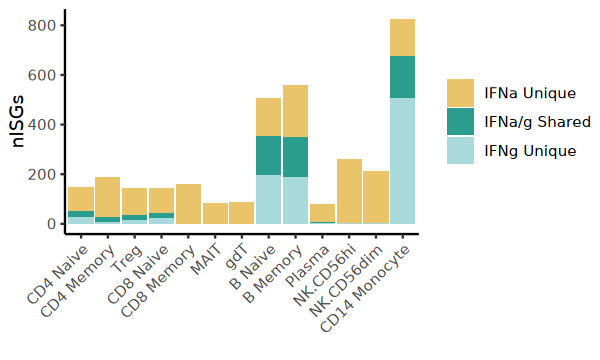

In [98]:
fig.size(3,5)
#pdf(file.path(fig_dir, "Fig3", "IFNa_IFNg_Barplot.pdf"), height = 3, width = 6)
ggplot(data=deg_count_final, aes(x=celltype, y=nISGs, fill=Group)) +
    geom_bar(stat="identity") + 
    scale_fill_manual(values=c( "#e9c46a", "#2a9d8f", "#a8dadc")) + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
         legend.title = element_blank()) + 
    xlab("") #+ 
    #geom_text(aes(label=nISGs), vjust=1.6, color="black", position = position_dodge(0.9),  angle = 90, size=3.5)
dev.off()

### 3D. Subtype IFNa/g Jaccard Heatmap

In [108]:
# extract IFNa and IFNg ISGs
degs_alpha_gamma <- l2_degs %>% filter(stim %in% c("IFNa", "IFNg") & Significant == "Yes") %>%
    mutate(celltype_stim = paste(celltype, stim, sep = "_"))

In [111]:
gene_sets <- split(degs_alpha_gamma$gene, degs_alpha_gamma$celltype_stim)

In [113]:
# add dummy empty entries to account for cell types with no ISGs
missing_entries <- expand.grid(unique(degs_alpha_gamma$celltype), unique(degs_alpha_gamma$stim)) %>% 
    mutate(Comb = paste(Var1, Var2, sep = "_")) %>% pull(Comb) %>% setdiff(names(gene_sets))

empty_entries <- setNames(rep(NA, length(missing_entries)), missing_entries)
gene_sets <- c(gene_sets, empty_entries) 

In [118]:
ifna_sets <- paste(subtypes, "IFNa", sep = "_")
ifng_sets <- paste(subtypes, "IFNg", sep = "_")

In [119]:
celltype_combinations <- data.frame(set1 = rep(ifna_sets, each = 13),
                                    set2 = rep(ifng_sets, 13)) %>% apply(1, as.list)

In [120]:
# Function to calculate Jaccard index
jaccard_index <- function(set1, set2) {
  intersection_size <- length(intersect(set1, set2))
  union_size <- length(base::union(set1, set2))
  return(intersection_size / union_size)
}


jaccard_results <- data.frame(
  Subtype_Stim1 = character(),
  Subtype_Stim2 = character(),
  jaccard_index = numeric()
)


In [ ]:
# run across cell type and stim combinations
for (pair in celltype_combinations) {
    
  set1 <- gene_sets[pair[[1]]][[1]]
  set2 <- gene_sets[pair[[2]]][[1]]
 
     
  jaccard_value <- jaccard_index(set1, set2)
  
  jaccard_results <- rbind(jaccard_results, data.frame(
    celltype1 = pair[[1]],
    celltype2 = pair[[2]],
    jaccard_index = jaccard_value
  ))
}

In [ ]:
jaccard_results$celltype1 <- factor(jaccard_results$celltype1, levels = ifna_sets)
jaccard_results$celltype2 <- factor(jaccard_results$celltype2, levels = ifng_sets)
jaccard_results[is.na(jaccard_results)] <- 0

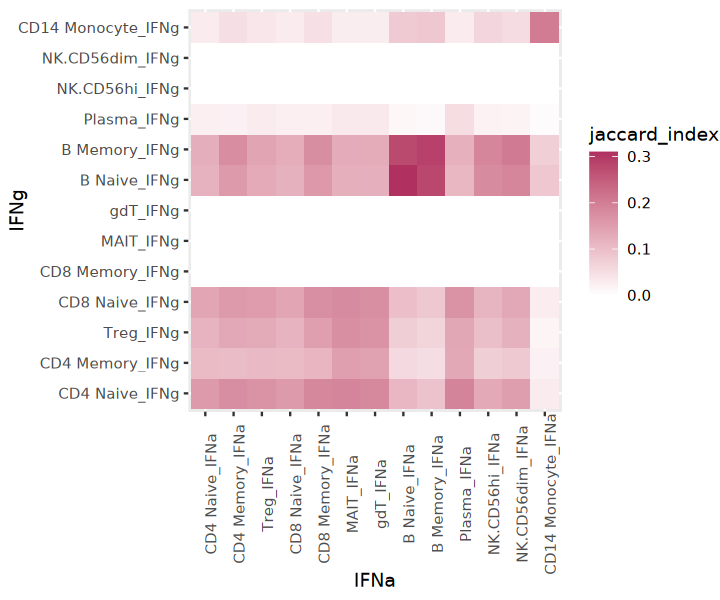

In [125]:
fig.size(5,6)
#pdf(file.path(fig_dir, "Fig3", "IFNa_IFNg_Jaccard_Heatmap.pdf"), height = 3, width = 6)
ggplot(jaccard_results, aes(celltype1, celltype2, fill= jaccard_index)) + 
  geom_tile() +
  scale_fill_gradient(low="white", high="maroon") +
  theme(axis.text.x = element_text(angle = 90)) + 
    labs(x = "IFNa", y = "IFNg") 
dev.off() 

### 3E. IFNa/IFNg Responding Non-Responding Cell Types Heatmap

In [27]:
stims_select <- c("IFNa", "IFNg")
subtypes_select <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "B Naive", "B Memory", "Plasma", "CD14 Monocyte")

In [28]:
l2_degs_select <- l2_degs %>% 
                filter(stim %in% stims_select & Significant == "Yes" & celltype %in% subtypes_select) %>% 
                mutate(Subtype_Stim = paste(celltype, stim, sep = "_"))

In [29]:
# group non-responding cell types together and take median logFC
degs_nonresponding <- l2_degs %>% 
    filter(stim %in% stims_select & Significant == "Yes" & celltype %in% setdiff(subtypes, subtypes_select)) %>% 
    group_by(gene, stim) %>%
    summarise(celltype = "IFNg Nonresponding",
              median_pval = mean(median_pval),
           Subtype_Stim = paste("IFNg Nonresponding", stim, sep = "_"),
        median_log2FC = mean(median_log2FC)) %>% unique()

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
`summarise()` has grouped output by 'gene', 'stim'. You can override using the
`.groups` argument.


In [30]:
# combine responding and non-respoding DFs
degs_final <- rbind(l2_degs_select %>% select(gene, median_log2FC, celltype, stim, Subtype_Stim), 
                    degs_nonresponding %>% select(gene, median_log2FC, celltype, stim, Subtype_Stim))
subtypes_final <- degs_final$celltype %>% unique

In [31]:
# add dummy row of 0s for IFNg Nonresponding IFNg stim column
l2_degs_heatmap <- degs_final %>% rbind(data.frame(gene = "IFI6", 
                               median_log2FC = 0,
                               celltype = "IFNg Nonresponding",
                               stim = "IFNg",
                               Subtype_Stim = "IFNg Nonresponding_IFNg"))

In [32]:
mat <- l2_degs_heatmap %>% arrange(celltype, stim) %>%
            pivot_wider(!c(celltype, stim),
                     names_from = Subtype_Stim, values_from = median_log2FC) %>% tibble::column_to_rownames("gene") %>%
    as.matrix()
mat[is.na(mat)] <- 0

Warning message:
“Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
ℹ Please explicitly name `id_cols`, like `id_cols = !c(celltype, stim)`.”


In [33]:
HA <- ComplexHeatmap::HeatmapAnnotation(df = data.frame(Stim = rep(stims_select, 9)), 
                                        col = list(Stim = c("IFNa" = "#f4a261", 
                                                               "IFNg" = "#264653"
                  )))


In [34]:
genes_select <- l2_degs_select %>% filter(celltype %in% subtypes_select) %>% group_by(Subtype_Stim) %>% 
    slice_max(abs(median_log2FC), n = 6) %>% 
    pull(gene) %>% unique()

null device 
          1

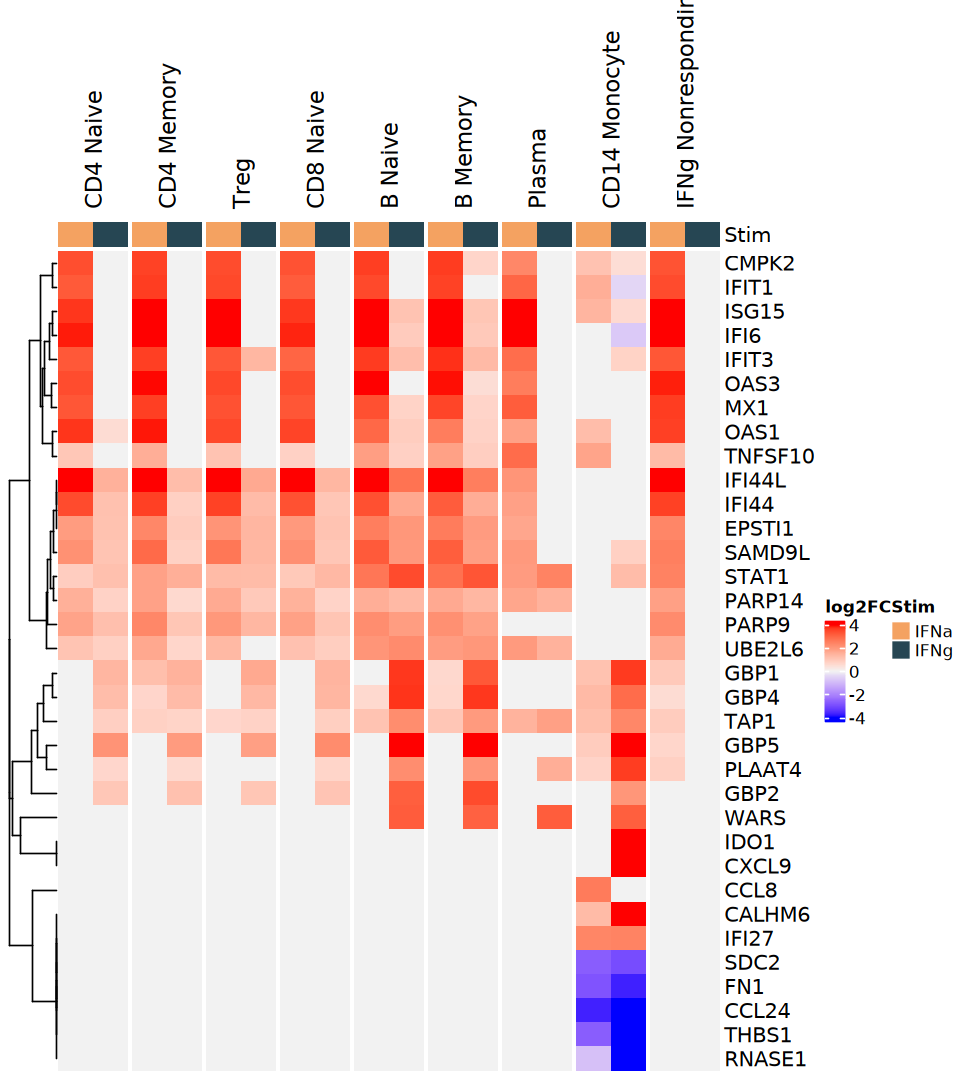

In [37]:
fig.size(9,8)

#pdf(file.path(fig_dir, "Fig3", "IFNa_IFNg_Responding_Nonresponding_Heatmap.pdf"), height = 9, width = 8)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray95", "red"))
p1 <- ComplexHeatmap::Heatmap(mat[genes_select,], name = "log2FC", top_annotation = HA, 
                        show_row_names = T, show_column_names = F, col = col_fun, cluster_rows = T,
                        column_split = factor(rep(subtypes_final, each = 2), levels = subtypes_final), cluster_columns = F, 
                        cluster_column_slices = F, clustering_distance_rows = "binary",
                        column_title_rot = 90
                        )
p1
dev.off()

### 3F. IFNa IFNg Monocyte Flow RNA Heatmap

In [38]:
# read-in flow results from tested monocyte IFNa and IFNg specific genes
flow_ifna <- fread(file.path(wd, "IFNa_Monocyte_ISGs_Flow.csv")) %>% mutate(Stim = "IFNa")
flow_ifng <- fread(file.path(wd, "IFNg_Monocyte_ISGs_Flow.csv")) %>% mutate(Stim = "IFNg")
flow_final <- rbind(flow_ifna, flow_ifng) %>% 
    pivot_longer(!c(Gene, Stim), names_to = "Donor", values_to = "logFC")

In [39]:
# ensure names are uniform across Flow and RNA
genes <- flow_final$Gene %>% unique()
rna_genes <- genes %>% recode(
                    "CD300e" = "CD300E", 
                    "CD11c" = "ITGAX",
                    "CD31" = "PECAM1", 
                    "CD62L" = "SELL", 
                    "CD64" = "FCGR1A", 
                    "PDL1" = "CD274")

In [40]:
# get logFC per donor across IFNa and IFNg stims
donors <- c("3955BW", "3283BW", "2616BW", "6811BW", "3491BW")
degs <- map_dfr(stims_select, function(i){
              map_dfr(donors, function(d){
              open <- fread(file.path(wd, "DEGs", "MAST_N1_downsample", "Bulk_All", "Monocyte", 
                                      glue("{d}_{i}_Monocyte_DEGs_MAST_CDR_downsample1000_consensus.csv"))) %>% filter(gene %in% rna_genes)
                    
              if (nrow(open) > 0){
                  open$Stim <- i
                  open$Donor <- d
                  open
              }
            
        })   
    })
degs$Stim_Donor <- paste(degs$Stim, degs$Donor, sep = "_")

In [41]:
# combine RNA and Flow results
rna_final <- degs %>% select(gene, Donor, iteration_median_log2FC, Stim) 

rna_final$gene <- recode(rna_final$gene, 
                    "CD300E" = "CD300e", 
                    "ITGAX" = "CD11c",
                    "PECAM1" = "CD31", 
                    "SELL" = "CD62L", 
                    "FCGR1A" = "CD64", 
                    "CD274" = "PDL1")

flow_final$Assay <- "Flow"
rna_final$Assay <- "RNA"

colnames(rna_final) <- c("Gene", "Donor", "logFC", "Stim", "Assay")

rna_final <- as.data.frame(rna_final)[,colnames(flow_final)]

df_final <- rbind(flow_final, rna_final) %>% arrange(Stim, Assay)

In [42]:
mat <- df_final %>% mutate(Stim_Assay_Donor = paste(Stim, Assay, Donor, sep = "_")) %>% select(Gene, Stim_Assay_Donor, logFC) %>% 
    pivot_wider(names_from = Stim_Assay_Donor, values_from = logFC)

In [43]:
meta <- df_final %>% select(Donor, Stim, Assay) %>% unique()
HA <- ComplexHeatmap::HeatmapAnnotation(df = meta %>% select(Stim, Assay), 
                                        col = list(Stim = c("IFNa" = "#f4a261",
                                                            "IFNg" = "#264653"
                  )))

In [44]:
mat <- mat %>% tibble::column_to_rownames("Gene")
mat[is.na(mat)] <- 0

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


null device 
          1

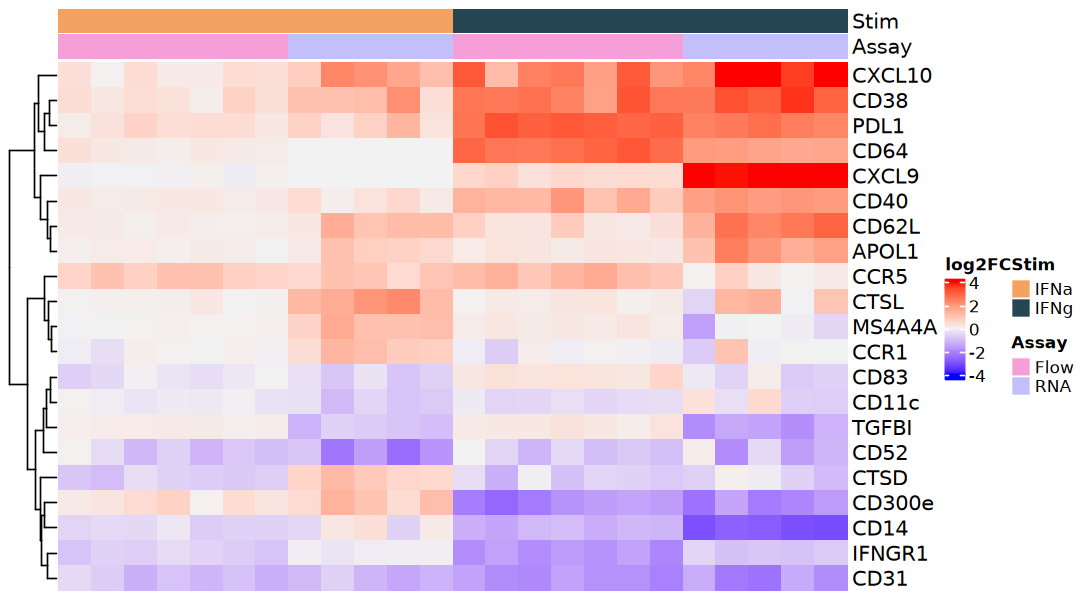

In [47]:
fig.size(5,9)
#pdf(file.path(fig_dir, "Fig3", "IFNa_g_Monocyte_Flow_RNA_Heatmap.pdf"), height = 5, width = 9)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray95", "red"))
ComplexHeatmap::Heatmap(mat, name = "log2FC", top_annotation = HA, 
                        show_row_names = T, show_column_names = F, col = col_fun, 
                        #column_split = factor(rep(stims, each = 5), levels = stims),
                        cluster_columns = F, 
                        cluster_column_slices = F, cluster_rows = T,
                        #clustering_distance_rows = "manhattan",
                        column_title_rot = 90
                        ) 
dev.off()

### 3G. IFNa IFNg Monocyte Flow RNA Correlation Scatterplot

In [48]:
median_df_final <- df_final %>% group_by(Gene, Stim, Assay) %>% 
    summarise(median_log2FC = median(logFC)) %>% 
    pivot_wider(names_from = Assay, values_from = median_log2FC)

`summarise()` has grouped output by 'Gene', 'Stim'. You can override using the
`.groups` argument.


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


null device 
          1

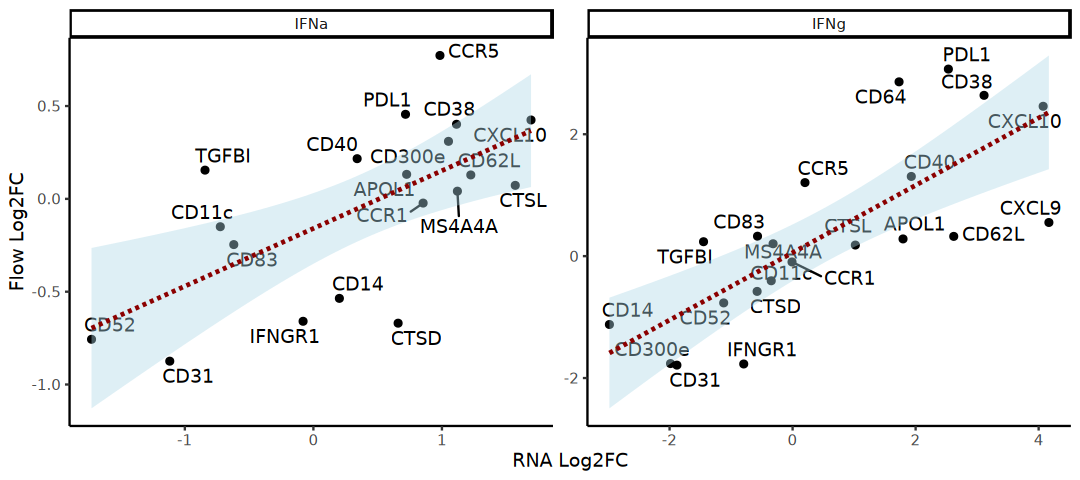

In [49]:
fig.size(4,9)
#pdf(file.path(fig_dir, "Fig3", "IFNa_g_Monocyte_Flow_RNA_Scatterplot.pdf"), height = 5, width = 11)
ggplot(median_df_final, aes(x=RNA, y=Flow)) +
    geom_point() + 
    facet_wrap(~Stim, scales = "free") + 
    theme_classic() + 
    ggrepel::geom_text_repel(label=median_df_final$Gene) + 
    geom_smooth(method=lm,  linetype="dashed", fullrange = T,
             color="darkred", fill="lightblue") + 
    labs(x = "RNA Log2FC", y = "Flow Log2FC")

dev.off()